# 04 — Model 1: gas recommendation (NG flow + air-fuel ratio)

**What the operator gets.** One recommendation per 20-min reversal cycle, ready by minute 15 so it can be set in the minute 15–20 window. It contains:
- **NG flow**, in the same unit as the workbook column `dcs_60_MelterGasflowvalue…` (no conversion, per plant). One value for both inlets (common header).
- **Air-fuel ratio**, and the matching secondary air flow.

**Inputs**
| Input | Source | Frequency |
|---|---|---|
| NCV | automatic (UEMS) | every 15 min, latest value |
| Draw, cullet % | operator | daily |
| Optical crown temperature | operator | current reading |
| Barrier + melter boost | **read from the DB** (plant decision: gas runs every 15 min, boost is recommended hourly) | last hour |

**Method** (chosen in `notebooks/training/T1` and `T2`)
1. **Daily gas-heat target:**
   - an OLS model on **all past usable days**: `gas_Gcal ~ draw + barrier_Gcal + melter_Gcal + furnace age + optical (previous 24 h)`
   - plus a **conformal shift**: the 25th percentile of the model's errors over the last 45 days
   - The result is the gas the efficient quarter of comparable recent days needed. Optical history is gap-filled from the crown thermocouple (+ offset).
2. **Steady heat over the day.** There is no separate optical trim; the crown effect is inside the model.
3. **NG = heat per 15 min ÷ latest NCV.** This is exact NCV compensation.
4. **Secondary air = air-per-Mcal target × heat**, and **AFR = secondary air ÷ NG**. The target is the P25 of the last 45 days, floored at the historical P5 (no O₂ analyser).
5. **Limits** = historical P1–P99. Back-tested with and without them.

**Back-test:** Jun–Aug 2026, walk-forward (each day only sees earlier days). Sep 2026 is the validation month once its draw arrives (§8).

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc
q = pd.read_parquet('../data/processed/ar_15min_clean.parquet')
h = pd.read_parquet('../data/processed/hourly_clean.parquet')
d = pd.read_parquet('../data/processed/daily_clean.parquet')
u = rc.prepare_gas_features(d[d.usable])
u['E_g'] = u.energy_kcal / 1e6
TEST_START, TEST_END = '2026-06-01', '2026-08-31'
test_days = u[(u.index >= TEST_START) & (u.index <= TEST_END)].index
print('usable days:', len(u), '| test days (Jun-Aug 2026):', len(test_days))

usable days: 316 | test days (Jun-Aug 2026): 85


## 1. Historical limits (P1–P99 of normal operation)

In [2]:
lim = rc.historical_limits(q, h)
LIMITS = {'ng_scm': tuple(lim.loc['ng_scm (per 15 min)', ['P1', 'P99']]), 'afr': tuple(lim.loc['afr', ['P1', 'P99']])}
lim.round(2)

,P1,median,P99
ng_scm (per 15 min),73.86,82.54,96.34
afr,10.99,12.17,13.44
air_per_mcal,1.20,1.27,1.34
bb_kwh (per hour),114.30,379.60,609.80
opt_temp (°C),1570.00,1575.00,1578.00
mb3_temp (°C),1316.14,1320.24,1325.56
crown_tc (°C),1559.17,1567.01,1573.75


## 2. The chosen target model vs the first version
Full model selection is in `notebooks/training/T1_gas_model_experiments.ipynb` (8 model types, 7 input sets, 2 test periods). Its summary is reloaded here, and the chosen model is compared with the first version (rolling 45-day quantile regression) on Jun–Aug 2026.

In [3]:
display(pd.read_csv(dp.PROCESSED / 'training_gas_final_variants.csv', index_col=0).round(3))
def pinball(y, p, t=0.25):
    e = y - p; return float(np.mean(np.maximum(t*e, (t-1)*e)))
te = u.loc[test_days]
tgt = rc.walk_forward_gas_targets(u, test_days)                         # chosen model
tgt_old = rc.walk_forward_gas_targets(u, test_days, method='qr_rolling')  # first version
pd.DataFrame({m: {'pinball': pinball(te.gas_g, t), 'share of days below target': (te.gas_g <= t).mean(),
                  'MAE (Gcal/day)': (te.gas_g - t).abs().mean(), 'implied energy saving %': 100*(te.gas_g - t).sum()/te.E_g.sum()}
              for m, t in [('chosen: OLS + ageing + optical + conformal', tgt), ('first version: rolling QR 45d', tgt_old)]}).T.round(3)

,pinball,coverage_min,coverage_max,mae,saving_pct
variant,,,,,
"+ optical (same day, filled)",0.327,0.247,0.300,0.909,0.559
+ crown thermocouple MC3,0.337,0.200,0.278,0.945,0.595
"+ optical (yesterday, filled)",0.338,0.235,0.256,0.948,0.597
winner (no crown temp),0.344,0.200,0.300,0.943,0.559
without barrier boost,0.437,0.306,0.356,1.159,0.627


,pinball,share of days below target,MAE (Gcal/day),implied energy saving %
chosen: OLS + ageing + optical + conformal,0.352,0.235,1.003,0.651
first version: rolling QR 45d,0.424,0.247,1.199,0.767


In [4]:
fin = smf.ols(rc.GAS_FORMULA, u[u.index < TEST_START].dropna(subset=rc.GAS_FEATURES)).fit()
print('Model fitted on data before the test period (Gcal/day):'); print(fin.params.round(3).to_dict())
print('-> +1 t/day draw: %+.2f Gcal/day gas | +1 Gcal/day barrier boost: %+.2f | +1 month age: %+.2f | +1 °C optical: %+.2f' % (
      fin.params.draw_t, fin.params.bb_g, fin.params.age_m, fin.params.opt_f_prev))

Model fitted on data before the test period (Gcal/day):
{'Intercept': 810.98, 'draw_t': 0.461, 'bb_g': -0.667, 'mb_g': -0.122, 'age_m': 0.301, 'opt_f_prev': -0.481}
-> +1 t/day draw: +0.46 Gcal/day gas | +1 Gcal/day barrier boost: -0.67 | +1 month age: +0.30 | +1 °C optical: -0.48


## 3. Is the frontier safe? Check the days that already ran at or below it
If days that used ≤ target gas had worse temperatures or quality, the target would be risky. Compare those days with the rest of the test period.

In [5]:
te = u.loc[test_days].copy(); te['target'] = tgt
te['at_or_below'] = te.gas_g <= te.target
chk = te.groupby('at_or_below')[['crown_tc', 'mb3_temp', 'opt_temp', 'seed_count', 'draw_t', 'bb_kwh']].mean()
chk.index = ['above target', 'at/below target']
chk.round(2)

,crown_tc,mb3_temp,opt_temp,seed_count,draw_t,bb_kwh
above target,1566.30,1321.97,1574.38,16.45,57.53,8650.06
at/below target,1566.43,1321.09,1574.59,14.80,56.09,7864.08


Days that already ran at or below the target had the same crown and bottom temperatures and no more seeds. So the frontier is operation the furnace has already shown it can do safely in the current conditions.

## 4. Within-day: steady heat, exact NCV compensation, secondary air first
- The day's target is spread evenly over 96 intervals.
- NG = heat ÷ latest NCV.
- Secondary air = air-per-Mcal target × heat (T2), and AFR = air ÷ NG.

In [6]:
AIR = pd.Series({day: rc.air_target(u, day) for day in test_days})
print('Air-per-Mcal target over the test period: %.3f-%.3f (median %.3f) | actual daily median %.3f' % (AIR.min(), AIR.max(), AIR.median(), te.air_per_mcal.median()))

Air-per-Mcal target over the test period: 1.258-1.283 (median 1.269) | actual daily median 1.280


## 5. Back-test at 15-min resolution (Jun–Aug 2026)

In [7]:
def backtest(use_limits=True, tau_target=tgt):
    rows = []
    for day in test_days:
        qd = q.loc[str(day.date())]
        for ts, r in qd.iterrows():
            if np.isnan(r.ncv) or np.isnan(r.ng_scm):
                continue
            rec = rc.recommend_gas(tau_target[day], r.ncv, AIR[day], LIMITS if use_limits else None)
            rows.append(dict(ts=ts, ncv=r.ncv, ng_actual=r.ng_scm, ng_rec=rec.ng_setpoint, afr_actual=r.afr,
                             afr_rec=rec.afr, air_actual=r.sec_air, air_rec=rec.sec_air, heat_actual=r.ng_scm*r.ncv, heat_rec=rec.ng_setpoint*r.ncv,
                             clipped=use_limits and not (LIMITS['ng_scm'][0] < rec.ng_setpoint < LIMITS['ng_scm'][1])))
    b = pd.DataFrame(rows).set_index('ts')
    b['date'] = b.index.normalize()
    return b

bt_A = backtest(use_limits=True)
bt_B = backtest(use_limits=False)
print('15-min recommendations:', len(bt_A), '| clipped by historical limits: %.1f%%' % (100*bt_A.clipped.mean()))

15-min recommendations: 8092 | clipped by historical limits: 0.0%


In [8]:
def daily_result(b, label):
    g = b.groupby('date').agg(heat_act=('heat_actual', 'sum'), heat_rec=('heat_rec', 'sum'), n=('heat_rec', 'size'))
    g = g.join(u[['gas_kcal', 'elec_kcal', 'energy_kcal', 'draw_kg', 'sfc', 'draw_t']])
    # scale the 15-min sums to the full day (a few 15-min slots lack NCV)
    g['gas_rec_day'] = g.gas_kcal * g.heat_rec / g.heat_act
    g['sfc_rec'] = (g.gas_rec_day + g.elec_kcal) / g.draw_kg
    g['scenario'] = label
    return g
dA, dB = daily_result(bt_A, 'A: within historical limits'), daily_result(bt_B, 'B: no limits')
summ = pd.DataFrame({s: {'actual SFC': g.sfc.mean(), 'recommended SFC': g.sfc_rec.mean(),
                         'SFC saving %': 100*(1 - g.sfc_rec.mean()/g.sfc.mean()),
                         'gas saving %': 100*(1 - g.gas_rec_day.sum()/g.gas_kcal.sum())} for s, g in [('A: within historical limits', dA), ('B: no limits', dB)]}).T
summ.round(2)

,actual SFC,recommended SFC,SFC saving %,gas saving %
A: within historical limits,1605.27,1593.25,0.75,0.9
B: no limits,1605.27,1593.25,0.75,0.9


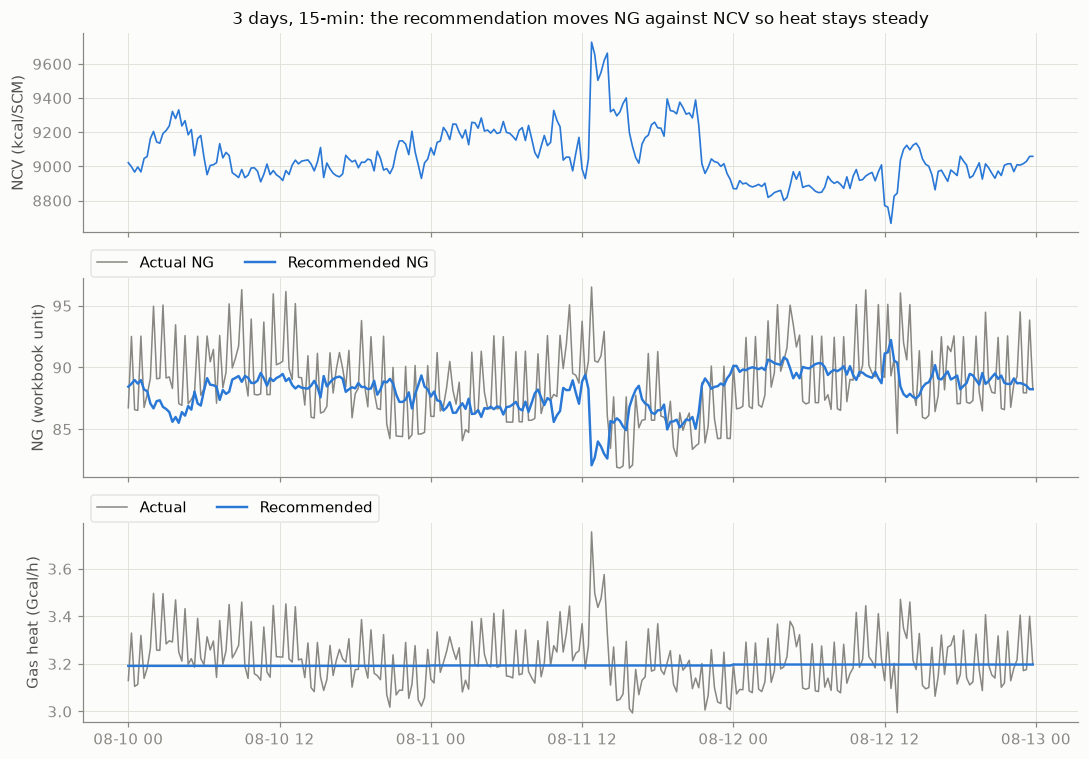

In [9]:
wk = bt_A.loc['2026-08-10':'2026-08-12']
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
ax[0].plot(wk.index, wk.ncv, color=BLUE, lw=1.1); ax[0].set_ylabel('NCV (kcal/SCM)')
ax[1].plot(wk.index, wk.ng_actual, color=MUTED, lw=1.0, label='Actual NG')
ax[1].plot(wk.index, wk.ng_rec, color=BLUE, lw=1.6, label='Recommended NG'); ax[1].set_ylabel('NG (workbook unit)'); ax[1].legend(loc='upper left', ncol=2, frameon=True, facecolor=SURF, edgecolor=GRID, bbox_to_anchor=(0, 1.18))
ax[2].plot(wk.index, wk.heat_actual*4/1e6, color=MUTED, lw=1.0, label='Actual')
ax[2].plot(wk.index, wk.heat_rec*4/1e6, color=BLUE, lw=1.6, label='Recommended'); ax[2].set_ylabel('Gas heat (Gcal/h)'); ax[2].legend(loc='upper left', ncol=2, frameon=True, facecolor=SURF, edgecolor=GRID, bbox_to_anchor=(0, 1.18))
ax[0].set_title('3 days, 15-min: the recommendation moves NG against NCV so heat stays steady')
plt.tight_layout(); plt.show()

The recommended NG moves exactly against NCV, so gas heat input stays flat at the day's target. Actual operation follows NCV only partly and also carries the reversal sawtooth.

## 6. Result per draw band and draw-adjusted (the two target views the client accepted)

In [10]:
base = u[u.in_baseline]
bins, labels = [45, 50, 55, 60, 65], ['45-50', '50-55', '55-60', '60-65']
band_base = base.groupby(pd.cut(base.draw_t, bins, labels=labels, include_lowest=True), observed=True).sfc.mean()
r = dA.copy(); r['band'] = pd.cut(r.draw_t, bins, labels=labels, include_lowest=True)
bt = r.groupby('band', observed=True).agg(days=('sfc', 'size'), actual=('sfc', 'mean'), recommended=('sfc_rec', 'mean'))
bt['baseline_band'] = band_base.reindex(bt.index); bt['target_2pct'] = bt.baseline_band * 0.98
bt['rec_vs_baseline_%'] = 100 * (bt.recommended / bt.baseline_band - 1)
bt['meets_target'] = bt.recommended <= bt.target_2pct
bt.round(1)

,days,actual,recommended,baseline_band,target_2pct,rec_vs_baseline_%,meets_target
band,,,,,,,
45-50,5,1769.9,1758.8,1765.9,1730.6,-0.4,False
50-55,18,1686.7,1685.7,1664.0,1630.8,1.3,False
55-60,33,1588.1,1571.1,1566.7,1535.4,0.3,False
60-65,29,1545.9,1532.6,1521.5,1491.1,0.7,False


In [11]:
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit()      # draw-adjusted M&V model (nb03, Model A)
r = r.join(u[['cullet_pct']])
r['E_exp'] = mA.predict(r) * 1e6
r['act_vs_exp_%'] = 100 * (r.energy_kcal / r.E_exp - 1)
r['rec_vs_exp_%'] = 100 * ((r.gas_rec_day + r.elec_kcal) / r.E_exp - 1)
print('Draw-adjusted (energy vs baseline model at the same draw & cullet), Jun-Aug 2026:')
print('  actual       %+.2f%%' % r['act_vs_exp_%'].mean())
print('  recommended  %+.2f%%   (target: -2.00%%)' % r['rec_vs_exp_%'].mean())

Draw-adjusted (energy vs baseline model at the same draw & cullet), Jun-Aug 2026:
  actual       +1.14%
  recommended  +0.37%   (target: -2.00%)


## 7. Secondary air and AFR
The gas back-test above counts only gas heat. Air affects energy indirectly (extra air is heated and leaves through the flue). That effect is estimated from the daily relationship in nb03/T2: energy residual vs air per Mcal.

In [12]:
mB = smf.ols('E_g ~ draw_t + cullet_pct + age_m', u[u.in_baseline]).fit()
ma = smf.ols('resid ~ air_per_mcal', u.assign(resid=u.E_g - mB.predict(u))).fit()
air_saving = (ma.params.air_per_mcal * (te.air_per_mcal - AIR).clip(lower=0)).sum() / te.E_g.sum() * 100
print('Air per Mcal: actual median %.3f -> target median %.3f | estimated extra energy saving %.2f%%' % (te.air_per_mcal.median(), AIR.median(), air_saving))
print('Secondary air: actual median %.0f, recommended median %.0f | AFR actual %.2f, recommended %.2f (historical P1-P99 %.2f-%.2f)' % (
      bt_A.air_actual.median(), bt_A.air_rec.median(), bt_A.afr_actual.median(), bt_A.afr_rec.median(), *LIMITS['afr']))
pd.Series({'air_saving_pct': air_saving}).to_csv(dp.PROCESSED / 'nb04_air_saving.csv')

Air per Mcal: actual median 1.280 -> target median 1.269 | estimated extra energy saving 0.18%
Secondary air: actual median 1039, recommended median 1026 | AFR actual 12.17, recommended 11.93 (historical P1-P99 10.99-13.44)


## 8. Live use and Sep 2026 validation

In [13]:
# Example: what the operator would see now (inputs typed / read from DB)
example_day = test_days[-1]
print('Daily gas target for', example_day.date(), '= %.1f Gcal' % tgt[example_day])
rec = rc.recommend_gas(tgt[example_day], ncv_now=9200, air_per_mcal=AIR[example_day], limits=LIMITS)
print('NCV 9200 -> NG %.1f (workbook unit), AFR %.2f, secondary air %.0f' % (rec.ng_setpoint, rec.afr, rec.sec_air))
rec = rc.recommend_gas(tgt[example_day], ncv_now=9600, air_per_mcal=AIR[example_day], limits=LIMITS)
print('NCV 9600 -> NG %.1f (workbook unit), AFR %.2f, secondary air %.0f' % (rec.ng_setpoint, rec.afr, rec.sec_air))

Daily gas target for 2026-08-31 = 77.5 Gcal
NCV 9200 -> NG 87.8 (workbook unit), AFR 11.67, secondary air 1024
NCV 9600 -> NG 84.1 (workbook unit), AFR 12.17, secondary air 1024


In [14]:
sep = d[(d.index >= '2026-09-01') & d.ncv_ok]
if sep.draw_kg.notna().sum() == 0:
    print('Sep 2026 validation: waiting for the September draw from the client (', len(sep), 'days with NCV ready ).')
else:
    print('Sep 2026 draw available -> rerun this notebook with TEST_START/END set to September.')

Sep 2026 validation: waiting for the September draw from the client ( 28 days with NCV ready ).


## 9. Summary
- **Model** (chosen in T1/T2):
  - **daily target:** OLS on all past usable days (draw, barrier and melter boost, furnace age, previous-day optical gap-filled from the thermocouple), shifted to the 25th percentile of the last 45 days' errors
  - **every 15 min:** spread evenly over the day and divided by the latest NCV
  - **secondary air:** air-per-Mcal target (rolling P25) × heat; AFR = air ÷ NG
- **Accuracy vs the first version:**
  - pinball loss 0.35 vs 0.42 and daily error 1.0 vs 1.2 Gcal, at realistic coverage (24% of days below target, 25% expected)
  - the first version's larger "saving" partly came from noisier targets
- **Safety:** days already at or below the target had normal crown and MB3 temperatures and fewer seeds.
- **Saving (Jun–Aug 2026):** **0.75% SFC** (0.9% of gas) versus actual operation, plus an estimated **0.18%** from air. With and without historical limits give the same result, because no recommendation reached the NG limits.
- **Against the targets:** draw-adjusted, the furnace moves from **+1.14%** to **+0.37%** with gas alone. Notebook 05 adds the boost lever and the combined result.